<a href="https://colab.research.google.com/github/abjin/abjin/blob/main/Linear%20Regression%20Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# My Linear Regression


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## generate sample data

In [2]:
SEED = 2023
SIZE = 50

In [3]:
np.random.seed(SEED)

In [4]:
def generateData(size):
     x = np.array(range(size))
     noise = np.random.uniform(-10,20, size)
     y = 3.5*x + noise
     return x,y

In [5]:
x,y = generateData(SIZE)
data = np.vstack([x,y])
data = data.T
data = np.array(data, dtype=np.float64)

print(data)
print('shape', data.shape)
print('dim', data.ndim)

[[  0.          -0.34035088]
 [  1.          20.21267355]
 [  2.          14.64156766]
 [  3.           4.29788281]
 [  4.           8.24023668]
 [  5.          21.53686777]
 [  6.          11.66268985]
 [  7.          36.31824138]
 [  8.          33.73162027]
 [  9.          37.84805716]
 [ 10.          38.69119781]
 [ 11.          43.54146794]
 [ 12.          43.83405658]
 [ 13.          40.0351691 ]
 [ 14.          49.82625531]
 [ 15.          47.36231021]
 [ 16.          56.13876079]
 [ 17.          54.90969842]
 [ 18.          64.72974203]
 [ 19.          57.56944631]
 [ 20.          76.94584947]
 [ 21.          69.60384476]
 [ 22.          76.61813373]
 [ 23.          81.79691348]
 [ 24.          79.52162425]
 [ 25.          80.61855509]
 [ 26.          94.64781674]
 [ 27.          90.37591512]
 [ 28.          99.35576268]
 [ 29.         119.41595878]
 [ 30.         117.8047914 ]
 [ 31.         121.62292713]
 [ 32.         119.90101672]
 [ 33.         129.24863442]
 [ 34.        

In [6]:
df = pd.DataFrame(data, columns=['x','y'])
print(df.head())

     x          y
0  0.0  -0.340351
1  1.0  20.212674
2  2.0  14.641568
3  3.0   4.297883
4  4.0   8.240237


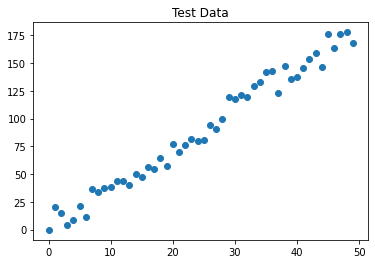

In [7]:
plt.title('Test Data')
plt.scatter(x = df['x'], y = df['y'])
plt.show()

### Split Data

In [8]:
train_rate = 0.7
val_rate = 0.15
test_rage = 0.15

In [9]:
x = df[['x']].values
y = df[['y']].values

In [10]:
shuffle = list(range(SIZE))
np.random.shuffle(shuffle)

x = x[shuffle]
y = y[shuffle]

print(shuffle)


[12, 24, 32, 43, 13, 9, 1, 39, 11, 0, 44, 16, 17, 10, 19, 38, 30, 45, 7, 42, 3, 48, 20, 4, 27, 23, 22, 31, 41, 47, 8, 34, 2, 33, 26, 15, 29, 5, 18, 21, 40, 36, 25, 37, 49, 14, 46, 28, 35, 6]


In [11]:
train_start = 0 
train_end = int(SIZE * train_rate)

val_start = train_end
val_end = int((train_rate + val_rate) * SIZE)

test_start = val_end
test_end = SIZE


In [12]:
x_train = x[train_start:train_end]
y_train = y[train_start:train_end]



x_val = x[val_start:val_end]
y_val = y[val_start:val_end]


x_test = x[test_start:test_end]
y_test = y[test_start:test_end]


In [13]:
N = len(x)
W = np.random.randn(1,1)
B = np.zeros((1, 1))
LEARNING_RATE = 0.0001

In [14]:
for epouch in range(100):
    y_pred = np.dot(x_train, W) + B

    cost = 1/N * np.sum((y_pred - y_train)**2)

    if(epouch % 10 == 0):
        print (f"Epoch: {epouch}, cost: {cost:.3f}, W: {W}, B: {B}")
    
    dw = -(2/N) * np.sum((y_train - y_pred) * x_train)
    db = -(2/N) * np.sum((y_train - y_pred))

    W = W -LEARNING_RATE * dw
    B = B -LEARNING_RATE * db


Epoch: 0, cost: 5299.796, W: [[0.55215289]], B: [[0.]]
Epoch: 10, cost: 574.338, W: [[2.67727163]], B: [[0.06520204]]
Epoch: 20, cost: 91.454, W: [[3.35659643]], B: [[0.08629578]]
Epoch: 30, cost: 42.110, W: [[3.57374718]], B: [[0.09328939]]
Epoch: 40, cost: 37.067, W: [[3.64315568]], B: [[0.09577556]]
Epoch: 50, cost: 36.552, W: [[3.66533572]], B: [[0.09682073]]
Epoch: 60, cost: 36.499, W: [[3.67241833]], B: [[0.09740517]]
Epoch: 70, cost: 36.493, W: [[3.67467478]], B: [[0.09784222]]
Epoch: 80, cost: 36.493, W: [[3.67538846]], B: [[0.09823206]]
Epoch: 90, cost: 36.492, W: [[3.67560898]], B: [[0.09860671]]


In [15]:
pred_train = W * x_train + B
pred_test = W * x_test + B

In [16]:
# Train and test MSE
train_mse = np.mean((y_train - pred_train) ** 2)
test_mse = np.mean((y_test - pred_test) ** 2)
print (f"train_MSE: {train_mse:.2f}, test_MSE: {test_mse:.2f}")

train_MSE: 52.13, test_MSE: 98.53


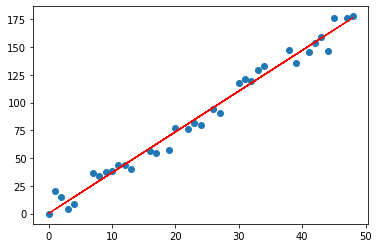

In [17]:
plt.plot(x_train, pred_train, color="red", linewidth=1, linestyle="-", label="model")
plt.scatter(x_train, y_train, label="y_train")

In [18]:
W,B

(array([[3.67567184]]), array([[0.09897641]]))